# Notebook 3 — Real-Data Validation: Can We Steer Migas?

NB1 mapped the architecture (convex gate, factual bottleneck). NB2 confirmed
on synthetic data. Now we test the real question: **given that we know the
ground truth, can we write text that makes the forecast more accurate?**

| Exp | Question | IV | Assets |
|-----|----------|----|--------|
| 3A | Do baselines work? | — | All 4 |
| 3B | Can accurate text steer the forecast toward GT? | Factual quality × predictive accuracy | All 4 |
| 3C | Does the factual bottleneck still bind under perfect oracle info? | Factual quality with exact leaked values | All 4 |

In [53]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

import os, sys
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from dotenv import load_dotenv

load_dotenv()
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

sys.path.insert(0, os.path.join(os.getcwd(), "synthefy-migas", "src"))
from migaseval import MigasPipeline
from migaseval.summary_utils import generate_summary

from experiment_utils import (
    build_summary, text_shift, directional_accuracy,
    make_series_df, load_financial_data, GENERIC_FACTUAL,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = MigasPipeline.from_pretrained("Synthefy/migas-1.5", device=device)
print(f"Device: {device}")

Initialized univariate model: chronos
Device: cpu


In [54]:
PRED_LEN = 8


def forecast(ctx, summary, dates=None):
    """Single forecast → (migas_fc, chronos_fc)."""
    df = make_series_df(ctx, dates)
    return pipeline.predict_from_dataframe(
        df, pred_len=PRED_LEN, summaries=[summary], return_univariate=True,
    )


def mae(pred, gt):
    return float(np.mean(np.abs(pred - gt)))


def pct_improve(mae_new, mae_baseline):
    if mae_baseline == 0:
        return 0.0
    return (mae_baseline - mae_new) / mae_baseline * 100


def craft_accurate_pred(gt, name):
    """Craft an analyst-style predictive signal from known GT values.
    Reads the actual trajectory and writes a natural expert assessment."""
    start, end = float(gt[0]), float(gt[-1])
    lo, hi = float(gt.min()), float(gt.max())
    pct = (end - start) / start * 100
    n = len(gt)
    mid = float(gt[n // 2])

    # Describe the shape of the trajectory
    first_half = "strengthening" if gt[n//2] > gt[0] else "weakening"
    second_half = "recovering" if gt[-1] > gt[n//2] else "continuing to decline"

    if abs(pct) < 3:
        return (
            f"{name} is expected to consolidate in a narrow range between "
            f"{lo:.0f} and {hi:.0f} over the coming {n} periods. No decisive "
            f"catalyst is emerging; positioning is balanced and volatility "
            f"should remain compressed."
        )
    elif pct > 0:
        return (
            f"Near-term outlook for {name} is constructive. Values are "
            f"advancing from {start:.0f}, {first_half} through {mid:.0f} "
            f"at the midpoint, before {second_half} toward {end:.0f}. "
            f"The {pct:+.1f}% total move within the {lo:.0f}–{hi:.0f} "
            f"range reflects sustained buying pressure and momentum."
        )
    else:
        return (
            f"Near-term outlook for {name} is challenging. Values are "
            f"retreating from {start:.0f}, {first_half} through {mid:.0f} "
            f"at the midpoint, then {second_half} toward {end:.0f}. "
            f"The {pct:+.1f}% total move within the {lo:.0f}–{hi:.0f} "
            f"range reflects building distribution pressure."
        )


def pred_exact_leak(gt):
    """Leak the exact future values into the predictive text."""
    vals = ", ".join(f"{v:.0f}" for v in gt)
    pct = (gt[-1] - gt[0]) / gt[0] * 100
    return (
        f"The exact expected values for the next {len(gt)} periods are: "
        f"{vals}. Overall change: {pct:+.1f}%."
    )


def print_summary(label, summary):
    """Pretty-print a complete summary that will be fed to the model."""
    print(f"\n{'─'*70}")
    print(f"  {label}")
    print(f"{'─'*70}")
    print(summary)


# ── Plot ──────────────────────────────────────────────────────────────────

COLORS = {
    "Chronos-2":          "dimgray",
    "generic+neutral":    "#95A5A6",
    "rich+neutral":       "#3498DB",
    "rich+accurate":      "#E67E22",
    "LLM-generated":      "#9B59B6",
    "rich+exact":         "#C0392B",
    "empty+exact":        "#E74C3C",
    "generic+exact":      "#2EAD6D",
}
FB = ["#2EAD6D", "#C0392B", "#2980B9", "#E67E22", "#9B59B6", "#1ABC9C"]


def plot_fc(ctx, gt, results, title, ylabel="Value"):
    """results: dict[label] → forecast array."""
    fig, ax = plt.subplots(figsize=(13, 4.5))
    n = len(ctx)
    t_ctx = range(n); t_fc = range(n, n + PRED_LEN)
    ax.plot(list(t_ctx)[-16:], ctx[-16:], "o-", color="steelblue",
            ms=3, lw=1.5, label="Context")
    ax.plot(t_fc, gt, "o-", color="black", ms=5, lw=2, label="Ground truth")
    for i, (lab, fc) in enumerate(results.items()):
        c = COLORS.get(lab, FB[i % len(FB)])
        style = "^--" if lab == "Chronos-2" else "s--"
        ax.plot(t_fc, fc, style, color=c, ms=4, lw=1.8, label=lab)
    ax.axvline(n - 0.5, color="gray", ls=":", alpha=0.4)
    ax.set_title(title, fontsize=11, fontweight=600)
    ax.set_ylabel(ylabel); ax.set_xlabel("Week")
    ax.legend(fontsize=7, loc="best")
    fig.tight_layout(); plt.show()


print(f"PRED_LEN = {PRED_LEN}  |  helpers ready")

PRED_LEN = 8  |  helpers ready


---
## Data loading

In [55]:
import yfinance as yf

TICKERS = {"S&P 500": "^GSPC", "Gold": "GLD", "Bitcoin": "BTC-USD"}
assets = {}

for name, ticker in TICKERS.items():
    vals, dates = load_financial_data(ticker, period="2y", interval="1wk")
    assets[name] = dict(
        ctx=vals[:-PRED_LEN], gt=vals[-PRED_LEN:],
        ctx_dates=dates[:-PRED_LEN], gt_dates=dates[-PRED_LEN:],
    )
    a = assets[name]
    pct = (a['gt'][-1] - a['gt'][0]) / a['gt'][0] * 100
    print(f"{name:10s}  ctx={len(a['ctx'])} wks  "
          f"GT: {a['gt'][0]:.0f} → {a['gt'][-1]:.0f}  ({pct:+.1f}%)")

S&P 500     ctx=97 wks  GT: 6932 → 6477  (-6.6%)
Gold        ctx=97 wks  GT: 455 → 401  (-12.0%)
Bitcoin     ctx=97 wks  GT: 70265 → 67592  (-3.8%)


In [72]:
cement_all = pd.read_csv("data/master_12Mar26_top20_skus_apr2025_onwards_weekly.csv")
cement_all["date"] = pd.to_datetime(cement_all["date"])

sku_stats = (
    cement_all.groupby(["sku", "SKU Name", "State"])["qty"]
    .agg(["mean", "std", "count"])
    .assign(cv=lambda x: x["std"] / x["mean"])
    .sort_values("cv", ascending=False)
    .reset_index()
)

sku_high = sku_stats.iloc[0]["sku"]


def load_sku(sku_id):
    s = cement_all[cement_all["sku"] == sku_id].sort_values("date")
    v = s["qty"].values.astype(np.float32)
    d = s["date"].dt.strftime("%Y-%m-%d").tolist()
    return dict(
        ctx=v[:-PRED_LEN], gt=v[-PRED_LEN:],
        ctx_dates=d[:-PRED_LEN], gt_dates=d[-PRED_LEN:],
        name=s.iloc[0]["sku"], state=s.iloc[0]["State"],
    )


assets["Cement"] = load_sku(sku_high)
a = assets["Cement"]
pct = (a['gt'][-1] - a['gt'][0]) / a['gt'][0] * 100
print(f"Cement     ctx={len(a['ctx'])} wks  "
      f"GT: {a['gt'][0]:.0f} → {a['gt'][-1]:.0f}  ({pct:+.1f}%)  "
      f"({a['name']}, {a['state']})")

Cement     ctx=41 wks  GT: 581747 → 657345  (+13.0%)  (AP1UT7T1081000UEND, Andhra Pradesh)


---
## Text definitions

All text that will be fed to the model is defined and **printed** here so
every prompt is inspectable before any forecast is run.

In [57]:
# ── Rich factual summaries (describe the CONTEXT window) ──────────────────

RICH_FACTUAL = {
    "S&P 500": (
        "The S&P 500 rallied from the low-4,000s to above 6,000 over the "
        "context window, powered by AI-driven mega-cap earnings and resilient "
        "consumer spending despite elevated rates. A mid-2024 consolidation "
        "near 5,200 coincided with renewed inflation fears but dip-buyers "
        "stepped in. The most recent weeks show the index near all-time highs "
        "with breadth narrowing and volatility at multi-year lows."
    ),
    "Gold": (
        "Gold rallied persistently, breaking above $2,000/oz and pushing toward "
        "$2,500 as central-bank purchases hit multi-decade highs and geopolitical "
        "tensions sustained safe-haven demand. A brief Q3 2024 pullback when "
        "real yields spiked reversed quickly as rate-cut expectations solidified. "
        "Recent weeks show consolidation near record highs."
    ),
    "Bitcoin": (
        "Bitcoin surged from ~$25,000 in late 2023 to above $90,000 by early "
        "2025, driven by spot-ETF approvals, the April 2024 halving, and broad "
        "risk-on rotation into digital assets. Recent weeks show a correction "
        "from highs with price holding above $80,000. On-chain data indicates "
        "long-term holders accumulating."
    ),
    "Cement": (
        "Weekly cement dispatches from the Andhra Pradesh plant show a pronounced "
        "seasonal pattern. Volumes were depressed during April–June 2025 "
        "(120,000–240,000 units/week) as monsoon stalled construction, then "
        "surged sharply from July — peaking above 860,000 in late September. "
        "The Oct–Mar period maintained elevated volumes (550,000–860,000) with "
        "swings driven by order timing and holidays. Recent weeks stabilize "
        "around 620,000–660,000."
    ),
}

print("=" * 70)
print("RICH FACTUAL SUMMARIES")
print("=" * 70)
for name, text in RICH_FACTUAL.items():
    print(f"\n[{name}]")
    print(text)

print("\n" + "=" * 70)
print("GENERIC FACTUAL (from experiment_utils)")
print("=" * 70)
print(GENERIC_FACTUAL)

RICH FACTUAL SUMMARIES

[S&P 500]
The S&P 500 rallied from the low-4,000s to above 6,000 over the context window, powered by AI-driven mega-cap earnings and resilient consumer spending despite elevated rates. A mid-2024 consolidation near 5,200 coincided with renewed inflation fears but dip-buyers stepped in. The most recent weeks show the index near all-time highs with breadth narrowing and volatility at multi-year lows.

[Gold]
Gold rallied persistently, breaking above $2,000/oz and pushing toward $2,500 as central-bank purchases hit multi-decade highs and geopolitical tensions sustained safe-haven demand. A brief Q3 2024 pullback when real yields spiked reversed quickly as rate-cut expectations solidified. Recent weeks show consolidation near record highs.

[Bitcoin]
Bitcoin surged from ~$25,000 in late 2023 to above $90,000 by early 2025, driven by spot-ETF approvals, the April 2024 halving, and broad risk-on rotation into digital assets. Recent weeks show a correction from highs w

In [58]:
# ── Neutral predictive (no GT knowledge) ─────────────────────────────────
NEUTRAL_PRED = "No strong directional signals. Expect continuation of recent trends."

# ── Accurate predictive signals (crafted FROM GT knowledge) ──────────────
ACCURATE_PRED = {}
for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    ACCURATE_PRED[name] = craft_accurate_pred(assets[name]["gt"], name)

# ── Exact-value oracle (literal GT leak) ─────────────────────────────────
EXACT_PRED = {}
for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    EXACT_PRED[name] = pred_exact_leak(assets[name]["gt"])

print("=" * 70)
print("PREDICTIVE SIGNALS")
print("=" * 70)

print("\n[NEUTRAL — shared across all assets]")
print(NEUTRAL_PRED)

for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    print(f"\n{'─'*70}")
    print(f"  {name}")
    print(f"{'─'*70}")
    print(f"\n  ACCURATE (crafted from GT knowledge):")
    print(f"  {ACCURATE_PRED[name]}")
    print(f"\n  EXACT LEAK (literal GT values):")
    print(f"  {EXACT_PRED[name]}")

PREDICTIVE SIGNALS

[NEUTRAL — shared across all assets]
No strong directional signals. Expect continuation of recent trends.

──────────────────────────────────────────────────────────────────────
  S&P 500
──────────────────────────────────────────────────────────────────────

  ACCURATE (crafted from GT knowledge):
  Near-term outlook for S&P 500 is challenging. Values are retreating from 6932, weakening through 6740 at the midpoint, then continuing to decline toward 6477. The -6.6% total move within the 6477–6932 range reflects building distribution pressure.

  EXACT LEAK (literal GT values):
  The exact expected values for the next 8 periods are: 6932, 6836, 6910, 6879, 6740, 6632, 6506, 6477. Overall change: -6.6%.

──────────────────────────────────────────────────────────────────────
  Gold
──────────────────────────────────────────────────────────────────────

  ACCURATE (crafted from GT knowledge):
  Near-term outlook for Gold is challenging. Values are retreating from 455, 

In [59]:
# ── LLM-generated summaries (GPT-4o-mini, no GT knowledge) ───────────────
llm_summaries = {}

for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    a = assets[name]
    df_ctx = make_series_df(a["ctx"], a["ctx_dates"])
    sums = generate_summary(
        name, df_ctx, pred_len=PRED_LEN,
        llm_provider="openai", llm_api_key=OPENAI_API_KEY,
        llm_model="gpt-4o-mini", n_summaries=1,
    )
    llm_summaries[name] = sums[0]

print("=" * 70)
print("LLM-GENERATED SUMMARIES (GPT-4o-mini, price data only, no GT)")
print("=" * 70)
for name, s in llm_summaries.items():
    print(f"\n[{name}]")
    print(s)

Calling openai to generate summary (price data only) …
Generating 1 summary(ies) …
  Generated summary 1/1

Generated 1 summary(ies):

**FACTUAL SUMMARY:**  
The historical data from March 2024 to January 2026 reveals a generally upward trend in values, starting at 5254.3501 on March 25, 2024, and fluctuating to a peak of 6966.2798 by January 5, 2026. The series shows a notable decline from 5254.3501 to 4967.2300 by April 15, 2024, a drop of approximately 5.5%. Following this, values rebounded, reaching a high of 6032.3799 by November 25, 2024, before experiencing a decline to 5074.0801 by March 31, 2025. The subsequent recovery saw values rise steadily, with significant increases observed in mid-2025, culminating in a peak of 6849.0898 by November 24, 2025. The data indicates volatility, with price movements ranging from lows of around 4967 to highs exceeding 6900, suggesting a market influenced by both cyclical trends and possibly external economic factors.

**PREDICTIVE SIGNALS:**  

In [60]:
# ── Build ALL complete summaries for every scenario ──────────────────────
# This is the exact text fed to the model. Inspect everything here.

all_summaries = {}  # all_summaries[asset][scenario_label] = complete_summary_string

for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    all_summaries[name] = {
        # 3A baselines
        "generic+neutral":  build_summary(GENERIC_FACTUAL, NEUTRAL_PRED),
        # 3B steering ladder
        "rich+neutral":     build_summary(RICH_FACTUAL[name], NEUTRAL_PRED),
        "rich+accurate":    build_summary(RICH_FACTUAL[name], ACCURATE_PRED[name]),
        "LLM-generated":    llm_summaries[name],
        "rich+exact":       build_summary(RICH_FACTUAL[name], EXACT_PRED[name]),
        # 3C factual bottleneck
        "empty+exact":      build_summary("", EXACT_PRED[name]),
        "generic+exact":    build_summary(GENERIC_FACTUAL, EXACT_PRED[name]),
    }

# Print every single summary
for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    print("\n" + "=" * 70)
    print(f"  COMPLETE SUMMARIES FOR: {name}")
    print("=" * 70)
    for label, summary in all_summaries[name].items():
        print_summary(f"{name} → {label}", summary)


  COMPLETE SUMMARIES FOR: S&P 500

──────────────────────────────────────────────────────────────────────
  S&P 500 → generic+neutral
──────────────────────────────────────────────────────────────────────
**FACTUAL SUMMARY:**
The series shows typical fluctuations in value levels.

**PREDICTIVE SIGNALS:**
No strong directional signals. Expect continuation of recent trends.

──────────────────────────────────────────────────────────────────────
  S&P 500 → rich+neutral
──────────────────────────────────────────────────────────────────────
**FACTUAL SUMMARY:**
The S&P 500 rallied from the low-4,000s to above 6,000 over the context window, powered by AI-driven mega-cap earnings and resilient consumer spending despite elevated rates. A mid-2024 consolidation near 5,200 coincided with renewed inflation fears but dip-buyers stepped in. The most recent weeks show the index near all-time highs with breadth narrowing and volatility at multi-year lows.

**PREDICTIVE SIGNALS:**
No strong directio

---
## Experiment 3A — Baselines (all assets)

Chronos-2 (univariate) and Migas with `generic+neutral` text on all 4 assets.
Establishes the MAE floor that steering experiments try to beat.

In [61]:
baselines = {}
rows_3a = []

for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    a = assets[name]
    migas_fc, chronos_fc = forecast(a["ctx"], all_summaries[name]["generic+neutral"],
                                    a["ctx_dates"])
    baselines[name] = {"chronos": chronos_fc, "migas_neutral": migas_fc}

    mae_c = mae(chronos_fc, a["gt"])
    mae_m = mae(migas_fc, a["gt"])
    rows_3a.append(dict(
        Asset=name,
        Chronos_MAE=mae_c, Migas_neutral_MAE=mae_m,
        Chronos_DirAcc=directional_accuracy(chronos_fc, a["gt"]),
        Migas_DirAcc=directional_accuracy(migas_fc, a["gt"]),
        Chronos_range=f"[{chronos_fc.min():.0f}, {chronos_fc.max():.0f}]",
    ))

tbl_3a = pd.DataFrame(rows_3a)
print("Exp 3A — Baselines")
print("=" * 80)
print(tbl_3a.to_string(index=False, float_format="{:.1f}".format))

Exp 3A — Baselines
  Asset  Chronos_MAE  Migas_neutral_MAE  Chronos_DirAcc  Migas_DirAcc    Chronos_range
S&P 500        187.8              196.2             0.4           0.4     [6920, 6934]
   Gold         23.1               23.4             0.4           0.4       [453, 472]
Bitcoin       3328.9             3437.3             0.6           0.6   [69298, 73320]
 Cement     166045.7           103746.9             0.4           0.4 [243912, 572526]


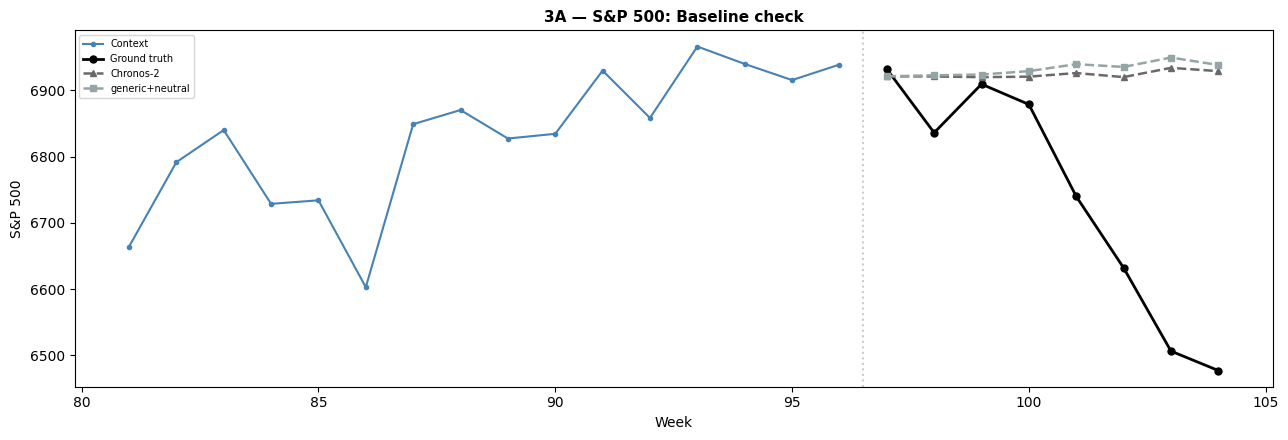

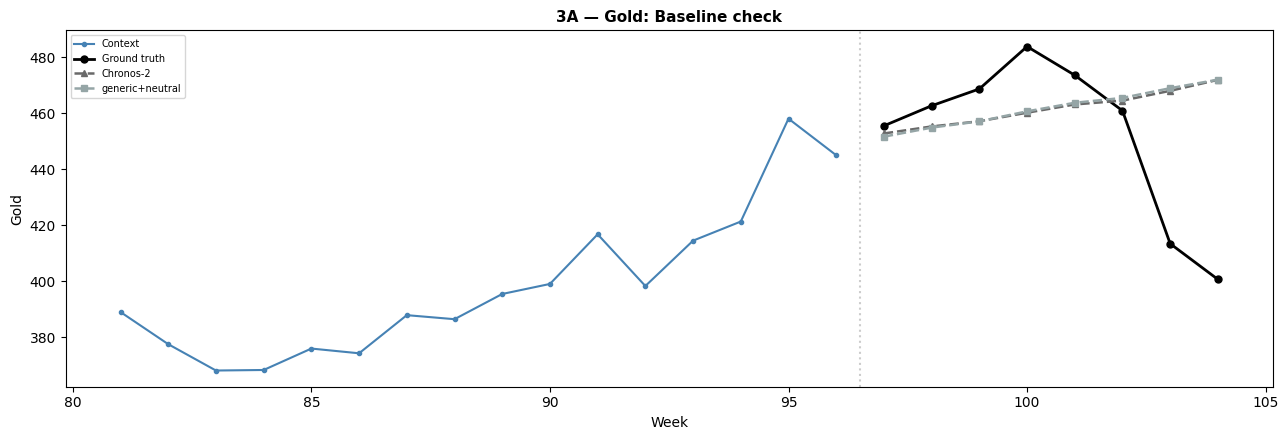

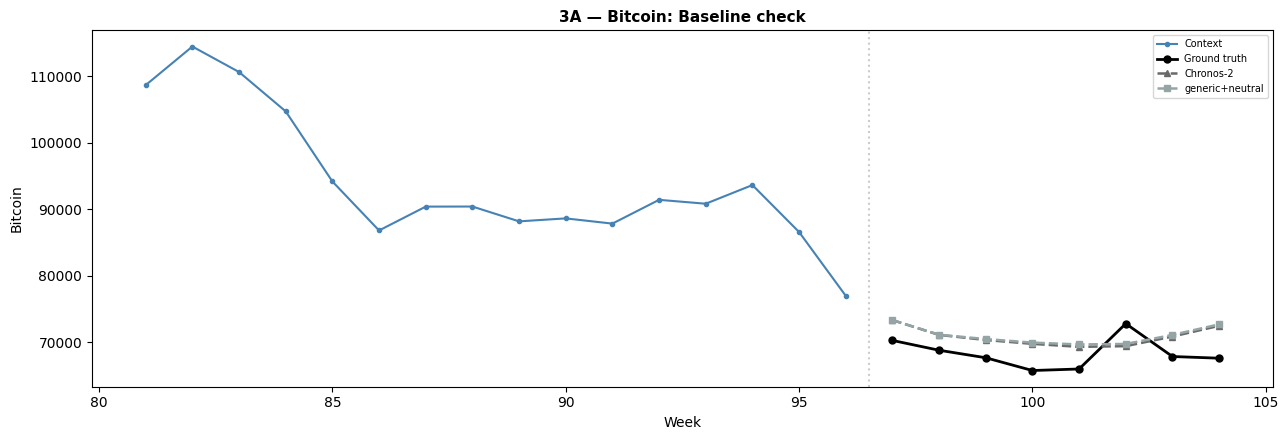

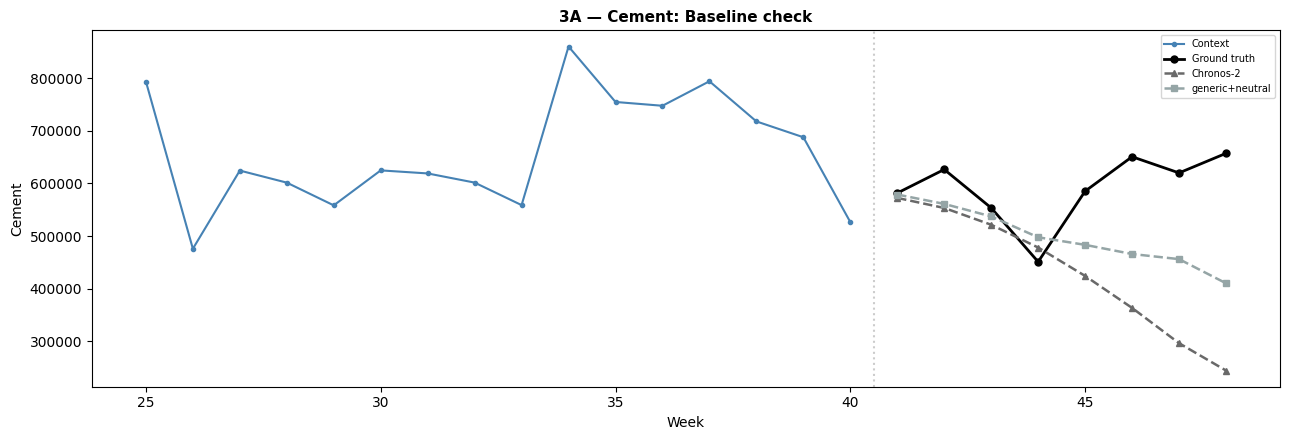

In [62]:
for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    a = assets[name]
    b = baselines[name]
    plot_fc(
        a["ctx"], a["gt"],
        {"Chronos-2": b["chronos"], "generic+neutral": b["migas_neutral"]},
        title=f"3A — {name}: Baseline check",
        ylabel=name,
    )

---
## Experiment 3B — Steering ladder (all assets)

**Question:** Given GT knowledge, can we write text that beats the baseline?

For every asset we test **5 scenarios**, progressing from no info to perfect info.
Each uses the rich factual summary (except baseline which uses generic).

| # | Scenario | Factual | Predictive | GT knowledge? |
|---|----------|---------|------------|---------------|
| 0 | generic+neutral | Generic | Neutral | None |
| 1 | rich+neutral | Rich (hand-crafted) | Neutral | None |
| 2 | rich+accurate | Rich (hand-crafted) | Accurate analyst text | Yes (direction, range, shape) |
| 3 | LLM-generated | LLM factual | LLM predictive | None (from price data only) |
| 4 | rich+exact | Rich (hand-crafted) | Exact leaked values | Yes (perfect) |

If the text channel works: MAE should decrease 0 → 1 → 2 → 4.

In [63]:
SCENARIOS_3B = ["generic+neutral", "rich+neutral", "rich+accurate",
                "LLM-generated", "rich+exact"]

results_3b = {}   # results_3b[asset][scenario] = forecast array
rows_3b = []

for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    a = assets[name]
    gt = a["gt"]
    chronos_base = baselines[name]["chronos"]
    mae_base = mae(chronos_base, gt)

    forecasts = {"Chronos-2": chronos_base}
    for sc in SCENARIOS_3B:
        m, _ = forecast(a["ctx"], all_summaries[name][sc], a["ctx_dates"])
        forecasts[sc] = m

    results_3b[name] = forecasts

    # Metrics
    for label, fc in forecasts.items():
        m_val = mae(fc, gt)
        rows_3b.append(dict(
            Asset=name, Scenario=label,
            MAE=m_val, DirAcc=directional_accuracy(fc, gt),
            TextShift=text_shift(fc, chronos_base),
            Improve_pct=pct_improve(m_val, mae_base),
        ))

tbl_3b = pd.DataFrame(rows_3b)
print("\nExp 3B — Steering Ladder (all assets)")
print("=" * 80)
for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    sub = tbl_3b[tbl_3b["Asset"] == name]
    print(f"\n  {name}")
    print(sub[["Scenario", "MAE", "DirAcc", "TextShift", "Improve_pct"]].to_string(
        index=False, float_format="{:.1f}".format))


Exp 3B — Steering Ladder (all assets)

  S&P 500
       Scenario   MAE  DirAcc  TextShift  Improve_pct
      Chronos-2 187.8     0.4        0.0          0.0
generic+neutral 196.2     0.4        8.5         -4.5
   rich+neutral 203.1     0.3       15.9         -8.2
  rich+accurate 192.8     0.6        6.7         -2.7
  LLM-generated 194.6     0.4        6.8         -3.6
     rich+exact 193.6     0.4        6.0         -3.1

  Gold
       Scenario  MAE  DirAcc  TextShift  Improve_pct
      Chronos-2 23.1     0.4        0.0          0.0
generic+neutral 23.4     0.4        0.6         -1.3
   rich+neutral 22.3     0.4        1.5          3.7
  rich+accurate 21.4     1.0        7.7          7.4
  LLM-generated 23.4     0.4        0.5         -0.9
     rich+exact 21.4     0.6        4.9          7.4

  Bitcoin
       Scenario    MAE  DirAcc  TextShift  Improve_pct
      Chronos-2 3328.9     0.6        0.0          0.0
generic+neutral 3437.3     0.6      190.8         -3.3
   rich+neutral 3

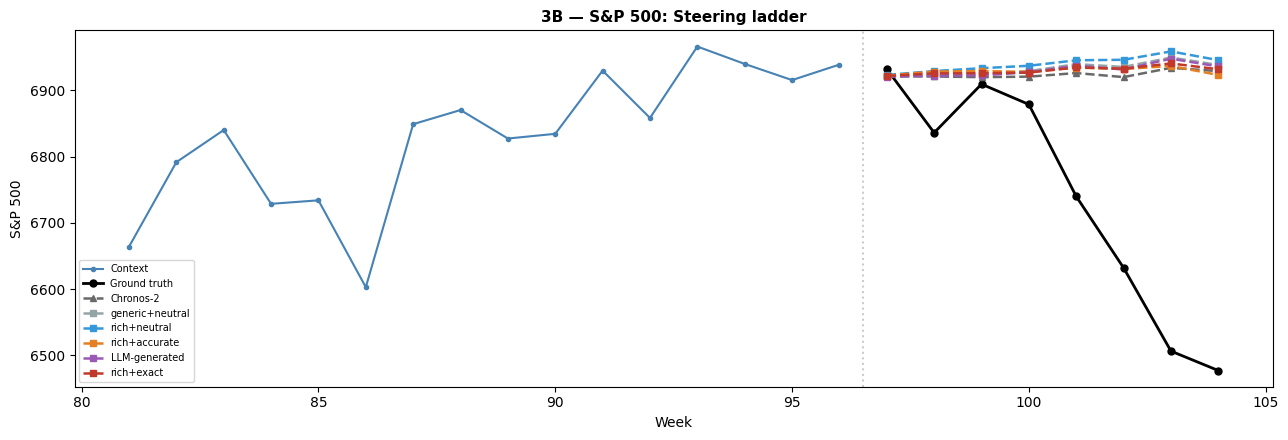

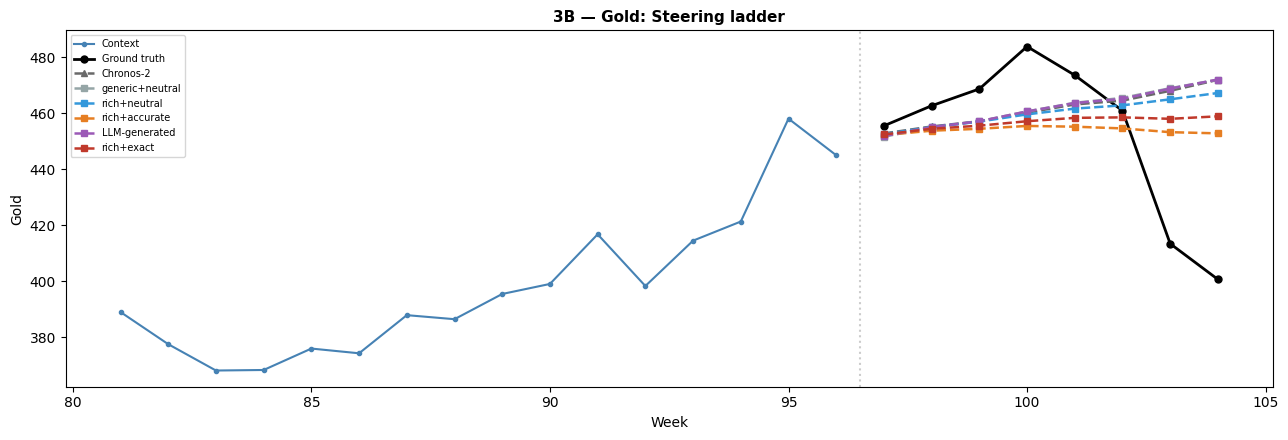

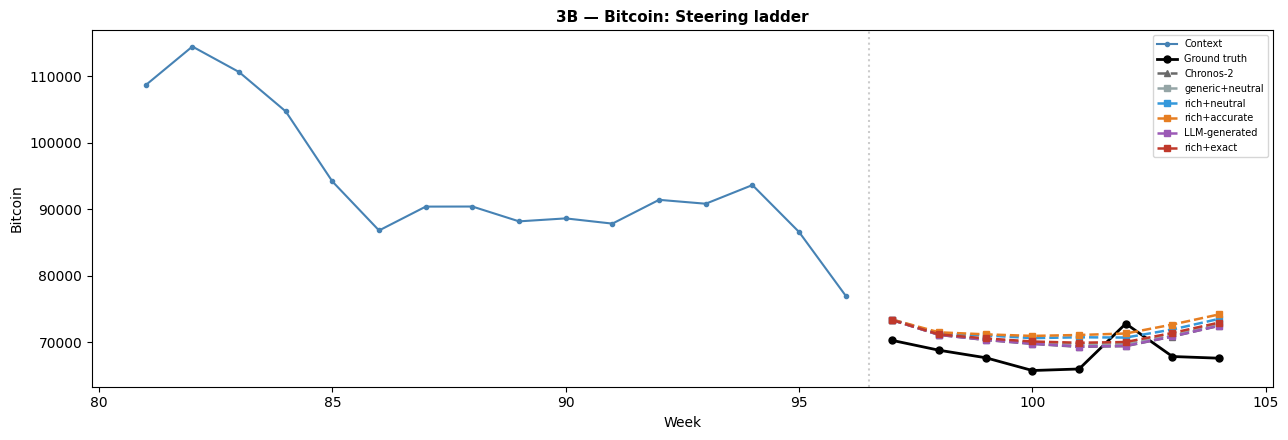

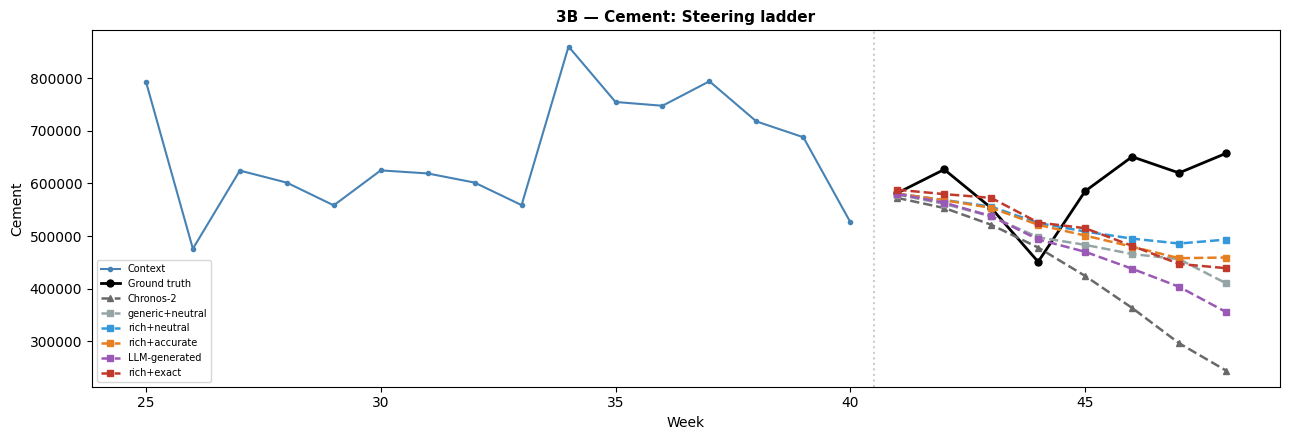

In [64]:
for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    a = assets[name]
    plot_fc(
        a["ctx"], a["gt"], results_3b[name],
        title=f"3B — {name}: Steering ladder",
        ylabel=name,
    )

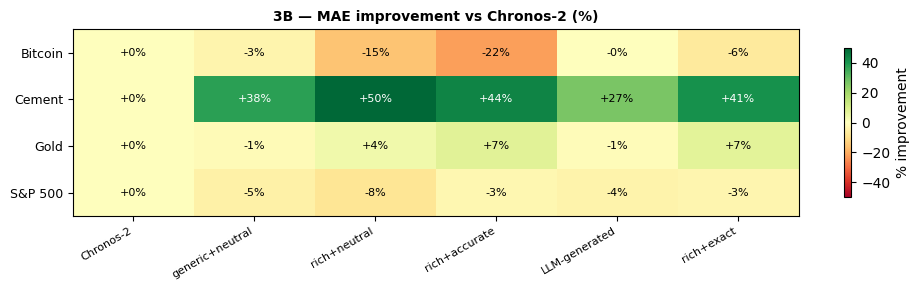

In [65]:
# Improvement heatmap
pivot = tbl_3b.pivot_table(index="Asset", columns="Scenario", values="Improve_pct")
col_order = [c for c in ["Chronos-2", "generic+neutral", "rich+neutral",
             "rich+accurate", "LLM-generated", "rich+exact"] if c in pivot.columns]
pivot = pivot[col_order]

fig, ax = plt.subplots(figsize=(10, 3))
im = ax.imshow(pivot.values, cmap="RdYlGn", aspect="auto", vmin=-50, vmax=50)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=30, ha="right", fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        v = pivot.values[i, j]
        ax.text(j, i, f"{v:+.0f}%", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 30 else "black")
ax.set_title("3B — MAE improvement vs Chronos-2 (%)", fontsize=10, fontweight=600)
fig.colorbar(im, ax=ax, shrink=0.8, label="% improvement")
fig.tight_layout(); plt.show()

---
## Experiment 3C — Value leakage × factual bottleneck

**Question:** When we give the model **perfect information** (exact future
values in the predictive text), does the factual quality bottleneck from NB1
still bind?

| Label | Factual | Predictive |
|-------|---------|------------|
| empty+exact | (empty string) | Exact future values |
| generic+exact | Generic | Exact future values |
| rich+exact | Rich hand-crafted | Exact future values |

**NB1 prediction:** rich factual → high convex weight w → text channel closes
→ model ignores even perfect predictive info.  
So: `empty+exact` < `generic+exact` < `rich+exact` in MAE (lower = better).

In [66]:
SCENARIOS_3C = ["empty+exact", "generic+exact", "rich+exact"]

results_3c = {}
rows_3c = []

for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    a = assets[name]
    gt = a["gt"]
    chronos_base = baselines[name]["chronos"]
    mae_base = mae(chronos_base, gt)

    forecasts = {"Chronos-2": chronos_base}
    for sc in SCENARIOS_3C:
        m, _ = forecast(a["ctx"], all_summaries[name][sc], a["ctx_dates"])
        forecasts[sc] = m

    results_3c[name] = forecasts

    for label, fc in forecasts.items():
        m_val = mae(fc, gt)
        rows_3c.append(dict(
            Asset=name, Scenario=label,
            MAE=m_val, DirAcc=directional_accuracy(fc, gt),
            Improve_pct=pct_improve(m_val, mae_base),
        ))

tbl_3c = pd.DataFrame(rows_3c)
print("Exp 3C — Value Leakage × Factual Bottleneck")
print("=" * 80)
for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    sub = tbl_3c[tbl_3c["Asset"] == name]
    print(f"\n  {name}")
    print(sub[["Scenario", "MAE", "DirAcc", "Improve_pct"]].to_string(
        index=False, float_format="{:.1f}".format))

Exp 3C — Value Leakage × Factual Bottleneck

  S&P 500
     Scenario   MAE  DirAcc  Improve_pct
    Chronos-2 187.8     0.4          0.0
  empty+exact 190.6     0.3         -1.5
generic+exact 191.2     0.3         -1.8
   rich+exact 193.6     0.4         -3.1

  Gold
     Scenario  MAE  DirAcc  Improve_pct
    Chronos-2 23.1     0.4          0.0
  empty+exact 20.9     0.6          9.5
generic+exact 23.0     0.4          0.5
   rich+exact 21.4     0.6          7.4

  Bitcoin
     Scenario    MAE  DirAcc  Improve_pct
    Chronos-2 3328.9     0.6          0.0
  empty+exact 3587.2     0.6         -7.8
generic+exact 3370.3     0.6         -1.2
   rich+exact 3541.3     0.6         -6.4

  Cement
     Scenario      MAE  DirAcc  Improve_pct
    Chronos-2 166045.7     0.4          0.0
  empty+exact  87909.3     0.4         47.1
generic+exact 127466.2     0.4         23.2
   rich+exact  97354.1     0.4         41.4


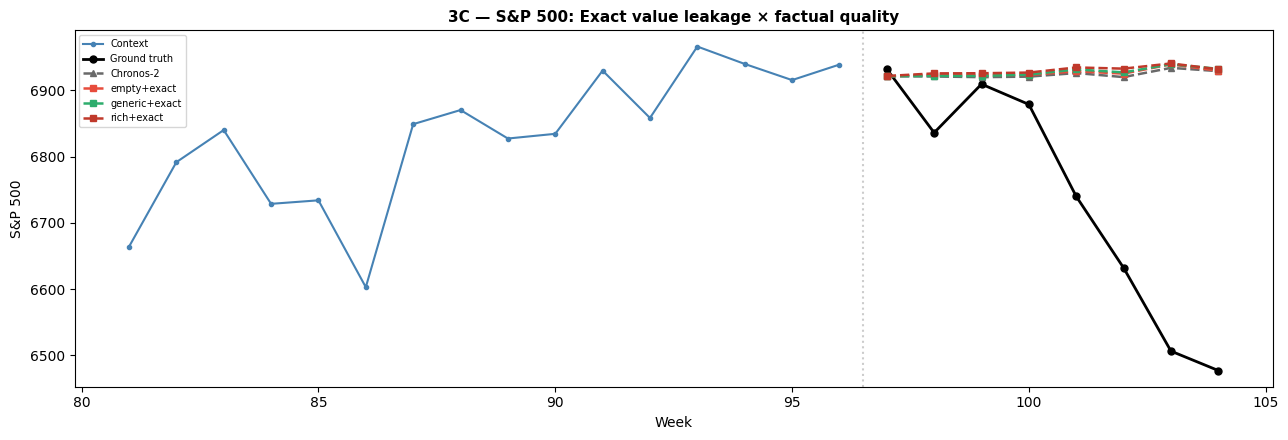

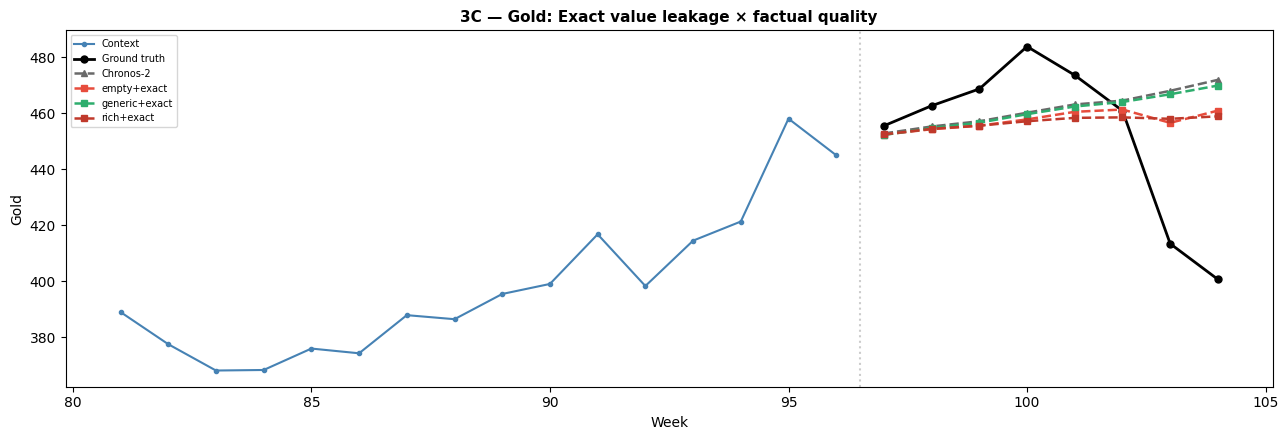

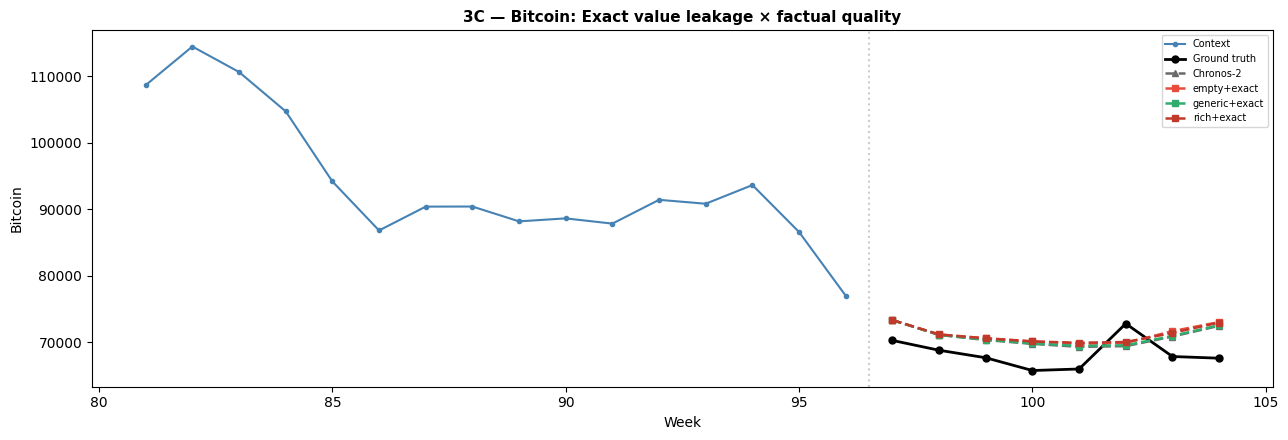

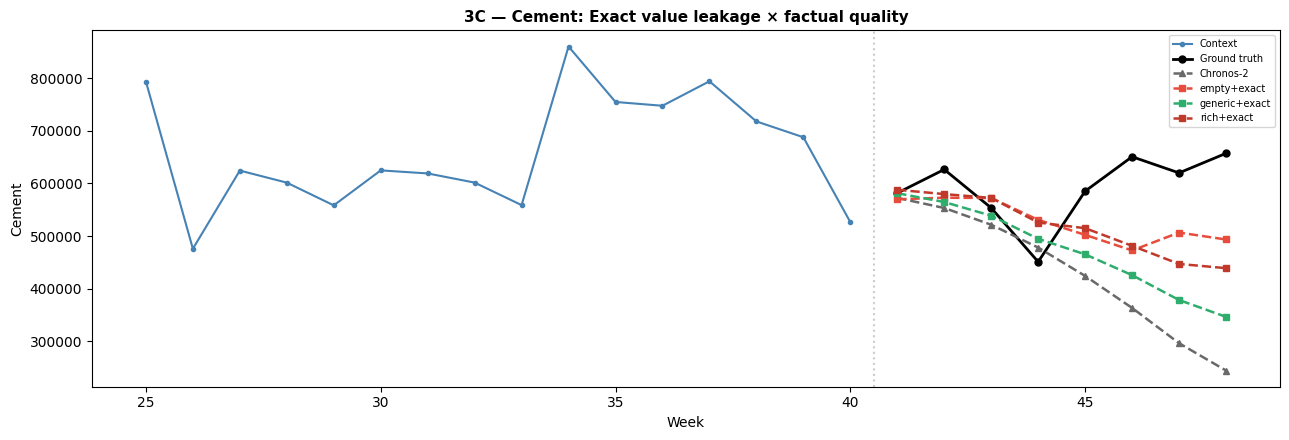

In [67]:
for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    a = assets[name]
    plot_fc(
        a["ctx"], a["gt"], results_3c[name],
        title=f"3C — {name}: Exact value leakage × factual quality",
        ylabel=name,
    )

In [68]:
# Bottleneck test: tabulate MAE for empty vs generic vs rich (all with exact oracle)
print("\nFactual bottleneck test — MAE with exact-value predictive:")
print(f"{'Asset':10s}  {'empty+exact':>12s}  {'generic+exact':>14s}  "
      f"{'rich+exact':>11s}  {'Chronos-2':>10s}")
print("─" * 65)
for name in ["S&P 500", "Gold", "Bitcoin", "Cement"]:
    fc = results_3c[name]
    gt = assets[name]["gt"]
    print(f"{name:10s}  {mae(fc['empty+exact'], gt):12.1f}  "
          f"{mae(fc['generic+exact'], gt):14.1f}  "
          f"{mae(fc['rich+exact'], gt):11.1f}  "
          f"{mae(fc['Chronos-2'], gt):10.1f}")

print("\nNB1 bottleneck prediction:")
print("  If confirmed: empty+exact < generic+exact < rich+exact (MAE)")
print("  i.e., richer factual = worse use of oracle predictive info")


Factual bottleneck test — MAE with exact-value predictive:
Asset        empty+exact   generic+exact   rich+exact   Chronos-2
─────────────────────────────────────────────────────────────────
S&P 500            190.6           191.2        193.6       187.8
Gold                20.9            23.0         21.4        23.1
Bitcoin           3587.2          3370.3       3541.3      3328.9
Cement           87909.3        127466.2      97354.1    166045.7

NB1 bottleneck prediction:
  If confirmed: empty+exact < generic+exact < rich+exact (MAE)
  i.e., richer factual = worse use of oracle predictive info


---
## Summary

In [69]:
print("=" * 70)
print("NOTEBOOK 3 — KEY RESULTS")
print("=" * 70)

print("\n--- 3A: Baselines ---")
print(tbl_3a.to_string(index=False, float_format="{:.1f}".format))

print("\n--- 3B: Steering Ladder (% MAE improvement vs Chronos-2) ---")
pivot_3b = tbl_3b.pivot_table(index="Asset", columns="Scenario", values="Improve_pct")
col_order_b = [c for c in ["generic+neutral", "rich+neutral", "rich+accurate",
               "LLM-generated", "rich+exact"] if c in pivot_3b.columns]
print(pivot_3b[col_order_b].to_string(float_format="{:+.1f}%".format))

print("\n--- 3C: Factual Bottleneck (% MAE improvement vs Chronos-2) ---")
pivot_3c = tbl_3c[tbl_3c["Scenario"] != "Chronos-2"].pivot_table(
    index="Asset", columns="Scenario", values="Improve_pct")
print(pivot_3c.to_string(float_format="{:+.1f}%".format))

print("\n--- Key questions answered ---")
print("1. 3A: Do baselines produce valid, non-zero forecasts on all assets?")
print("2. 3B: Does rich factual + accurate predictive beat generic + neutral?")
print("3. 3B: How does LLM-generated (no GT knowledge) compare to hand-crafted?")
print("4. 3C: Does the factual bottleneck suppress even perfect oracle info?")
print("   → If empty+exact beats rich+exact: NB1 bottleneck confirmed.")
print("=" * 70)

NOTEBOOK 3 — KEY RESULTS

--- 3A: Baselines ---
  Asset  Chronos_MAE  Migas_neutral_MAE  Chronos_DirAcc  Migas_DirAcc    Chronos_range
S&P 500        187.8              196.2             0.4           0.4     [6920, 6934]
   Gold         23.1               23.4             0.4           0.4       [453, 472]
Bitcoin       3328.9             3437.3             0.6           0.6   [69298, 73320]
 Cement     166045.7           103746.9             0.4           0.4 [243912, 572526]

--- 3B: Steering Ladder (% MAE improvement vs Chronos-2) ---
Scenario  generic+neutral  rich+neutral  rich+accurate  LLM-generated  rich+exact
Asset                                                                            
Bitcoin             -3.3%        -15.4%         -22.2%          -0.4%       -6.4%
Cement             +37.5%        +49.8%         +43.8%         +27.0%      +41.4%
Gold                -1.3%         +3.7%          +7.4%          -0.9%       +7.4%
S&P 500             -4.5%         -8.2%      